<a href="https://colab.research.google.com/github/Shrihariharan1999/Machine_Learning/blob/main/Decision_Tree_classifier_4th_june_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Titanic.csv")

In [ ]:
df.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.tail()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    object 
 13  embark_town  889 non-null    object 
 14  alive        891 non-null    object 
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


In [ ]:
df.describe()

,Unnamed: 0,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,445.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,445.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,667.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,890.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df=df.drop("Unnamed: 0",axis=1)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


<Axes: xlabel='sex', ylabel='survived'>

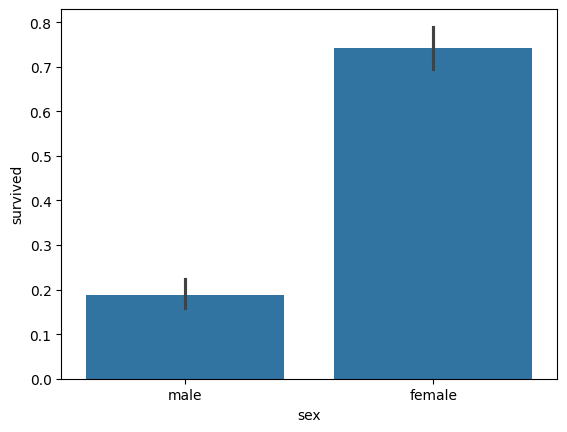

In [ ]:
sns.barplot(x='sex', y='survived', data=df)

In [ ]:
cat_col=df.select_dtypes(include="object").columns
cat_col


Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
for val in cat_col:
  df[val]=le.fit_transform(df[val])

In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,7,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,2,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,7,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,7,2,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2,1,1,True,7,2,0,True
887,1,1,0,19.0,0,0,30.0000,2,0,2,False,1,2,1,True
888,0,3,0,NaN,1,2,23.4500,2,2,2,False,7,2,0,False
889,1,1,1,26.0,0,0,30.0000,0,0,1,True,2,0,1,True


In [ ]:
nan_columns=df.columns[df.isnull().sum()>0]

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer=SimpleImputer(strategy='mean')

In [ ]:
for val in nan_columns:
  df[val]=imputer.fit_transform(df[[val]])

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


<Axes: >

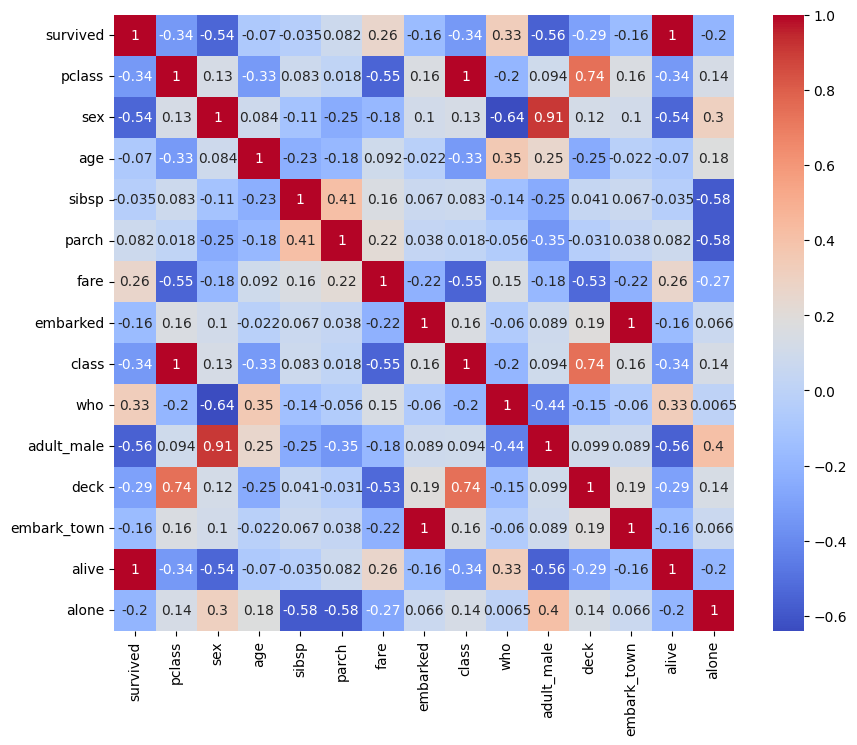

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

survived


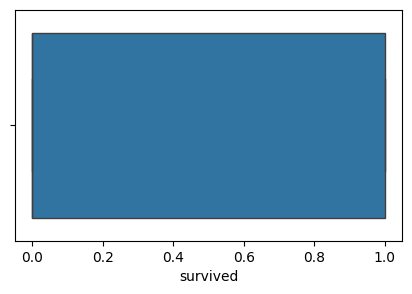

pclass


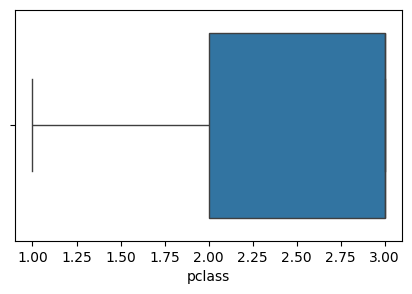

sex


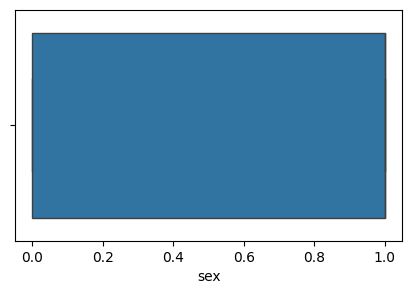

age


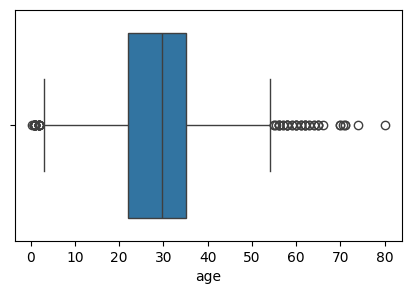

sibsp


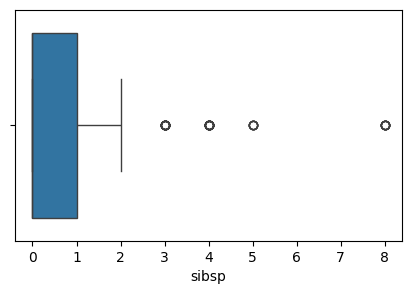

parch


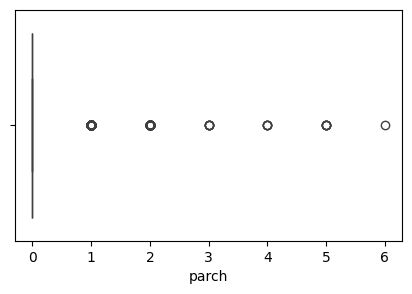

fare


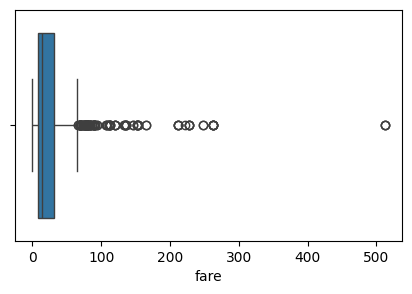

embarked


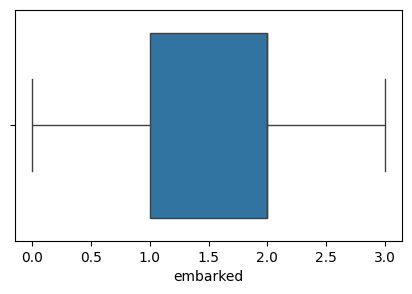

class


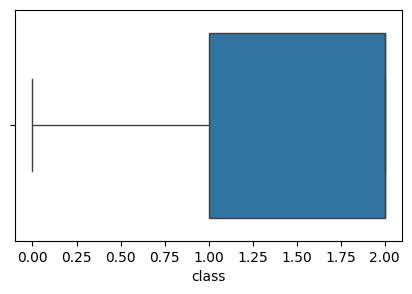

who


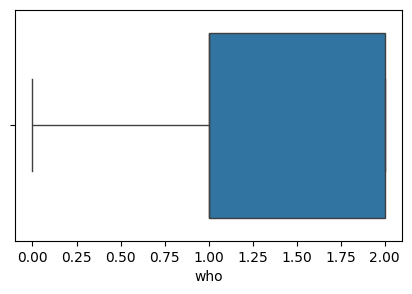

adult_male


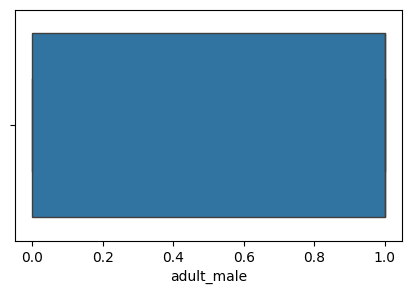

deck


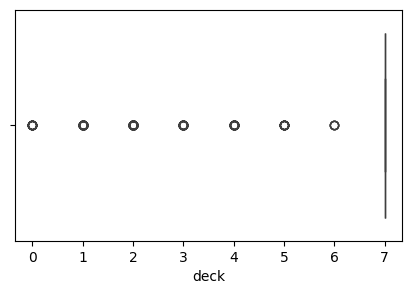

embark_town


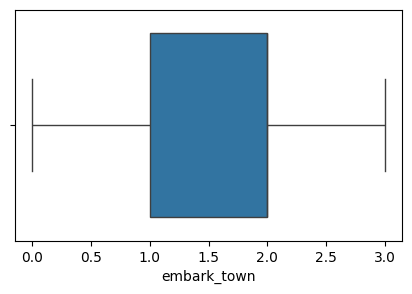

alive


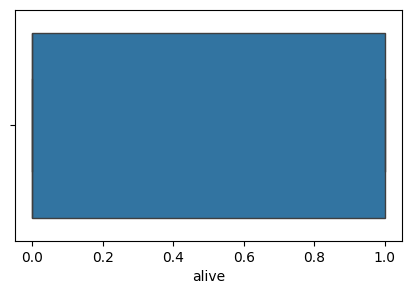

alone


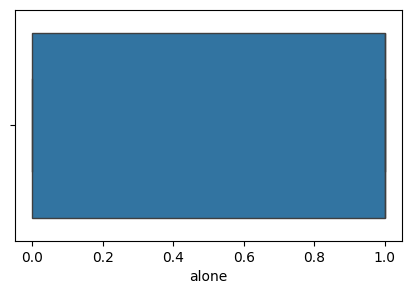

In [ ]:
for a in df.columns:
  print(a)
  plt.figure(figsize=(5,3))
  sns.boxplot(x=df[a])
  plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df_scaled = sc.fit_transform(df)

In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.000000,1,0,7.2500,2,2,1,True,7,2,0,False
1,1,1,0,38.000000,1,0,71.2833,0,0,2,False,2,0,1,False
2,1,3,0,26.000000,0,0,7.9250,2,2,2,False,7,2,1,True
3,1,1,0,35.000000,1,0,53.1000,2,0,2,False,2,2,1,False
4,0,3,1,35.000000,0,0,8.0500,2,2,1,True,7,2,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,2,1,1,True,7,2,0,True
887,1,1,0,19.000000,0,0,30.0000,2,0,2,False,1,2,1,True
888,0,3,0,29.699118,1,2,23.4500,2,2,2,False,7,2,0,False
889,1,1,1,26.000000,0,0,30.0000,0,0,1,True,2,0,1,True


<Axes: >

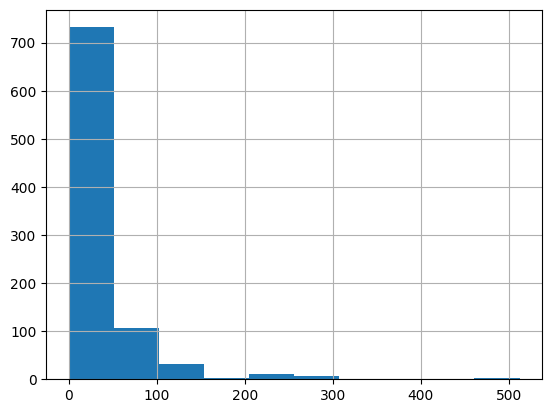

In [ ]:
df["fare"].hist()

<Axes: xlabel='alone', ylabel='survived'>

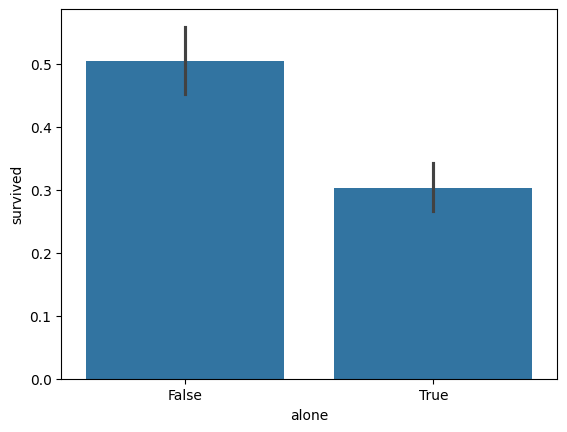

In [ ]:
sns.barplot(x="alone", y="survived", data=df)

In [ ]:
print(df['survived'].value_counts())

survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
df.groupby('alone')['survived'].mean()


,survived
alone,
False,0.505650
True,0.303538


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [ ]:
x=df.drop(["survived","alive"],axis=1)
y=df["survived"]
x,y

(     pclass  sex        age  sibsp  parch     fare  embarked  class  who  \
 0         3    1  22.000000      1      0   7.2500         2      2    1   
 1         1    0  38.000000      1      0  71.2833         0      0    2   
 2         3    0  26.000000      0      0   7.9250         2      2    2   
 3         1    0  35.000000      1      0  53.1000         2      0    2   
 4         3    1  35.000000      0      0   8.0500         2      2    1   
 ..      ...  ...        ...    ...    ...      ...       ...    ...  ...   
 886       2    1  27.000000      0      0  13.0000         2      1    1   
 887       1    0  19.000000      0      0  30.0000         2      0    2   
 888       3    0  29.699118      1      2  23.4500         2      2    2   
 889       1    1  26.000000      0      0  30.0000         0      0    1   
 890       3    1  32.000000      0      0   7.7500         1      2    1   
 
      adult_male  deck  embark_town  alone  
 0          True     7       

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((623, 13), (268, 13), (623,), (268,))

In [ ]:
model=DecisionTreeClassifier(random_state=50)

In [ ]:
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=50)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
acc=accuracy_score(y_test,y_pred)
acc

0.7649253731343284

In [ ]:
from sklearn.metrics import confusion_matrix


In [ ]:
cm=confusion_matrix(y_test,y_pred)

In [ ]:
cm

array([[138,  33],
       [ 30,  67]])

Text(0.5, 1.0, 'Confusion Matrix')

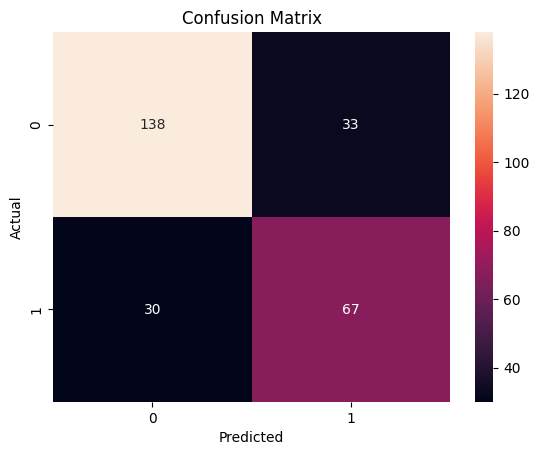

In [ ]:
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')